In [1]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from datamodules import data_processors
from rusmodules import eigenvals

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


In [2]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [3]:
path_archivo = "../input_data/combi_500_100.csv"
path_rand1 = "../input_data/uni_cp_1.csv"
path_rand2 = "../input_data/uni_cp_2.csv"
path_rand3 = "../input_data/uni_cp_3.csv"
path_rand4 = "../input_data/uni_cp_4.csv"
path_rand5 = "../input_data/uni_cp_5.csv"
datos_combi  = pd.read_csv(path_archivo)
datos_rand1 = pd.read_csv(path_rand1)
datos_rand2 = pd.read_csv(path_rand2)
datos_rand3 = pd.read_csv(path_rand3)
datos_rand4 = pd.read_csv(path_rand4)
datos_rand5 = pd.read_csv(path_rand5)
path_to_current_model = "models/isotropico_act_custom_6.keras" # colocar "none" si quiere entrenar un modelo

In [4]:
datos_rand1.head()

,phi_K,eta,beta,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,...,eig_13,eig_14,eig_15,eig_16,eig_17,eig_18,eig_19,Parallelepiped,Cylinder,Ellipsoid
0,0.125895,0.898143,1.591806,0.031749,1.294655,3.127039,5.615245,5.970742,8.054486,10.044170,...,25.940142,27.651893,31.884634,32.598213,42.472368,44.832121,44.864811,1,0,0
1,0.992284,1.877811,1.746430,1.334671,1.402422,2.148936,2.607121,3.248163,3.389296,3.549552,...,6.833653,7.702004,7.754664,8.325881,8.762108,9.016247,9.776120,1,0,0
2,1.144654,0.737189,2.996673,0.224183,1.108690,2.335793,4.800912,5.351783,5.719806,9.944617,...,41.782412,42.079959,42.402281,43.662518,44.339435,47.626037,49.234004,1,0,0
3,0.342128,1.479980,1.172628,0.146093,1.980160,3.718773,4.893354,5.723994,6.526462,6.954708,...,16.222019,16.529670,17.604798,17.897453,20.061791,25.946964,28.862689,1,0,0
4,0.820571,1.273627,1.306503,0.305105,1.224533,3.995201,4.104588,4.329762,6.219294,6.920863,...,14.445828,16.457301,17.106037,18.350513,18.884295,19.400193,20.926278,1,0,0


In [5]:
datos_combi = datos_combi.sort_values(by=["eta", "beta", "phi_K"]).reset_index(drop=True)

In [6]:
N_eig = 5
features = ["eta", "beta"] + list(map(lambda x: "eig_" + str(x+1), range(N_eig)))
target = "phi_K"
feat_targ = ["phi_K"] + ["eta", "beta"] + list(map(lambda x: "eig_" + str(x+1), range(N_eig)))

In [7]:
datos_combi = data_processors.preprocess_data(datos_combi, N_eig, target)
datos_rand1 = data_processors.preprocess_data(datos_rand1, N_eig, target)
datos_rand2 = data_processors.preprocess_data(datos_rand2, N_eig, target)
datos_rand3 = data_processors.preprocess_data(datos_rand3, N_eig, target)
datos_rand4 = data_processors.preprocess_data(datos_rand4, N_eig, target)
datos_rand5 = data_processors.preprocess_data(datos_rand5, N_eig, target)

In [8]:
datos_rand1.head()

,phi_K,eig_0,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5,x_0,x_1,x_2,x_3,x_4,x_5
0,0.080147,0.031749,0.898143,1.591806,0.772406,0.414020,0.556884,0.940460,0.741294,0.124154,0.036583,0.227499,0.308922,0.044137,0.258706
1,0.631707,1.334671,1.877811,1.746430,0.713052,0.652612,0.824256,0.802645,0.958359,0.295047,0.118733,0.220256,0.135186,0.189137,0.041641
2,0.728709,0.224183,0.737189,2.996673,0.901966,0.474652,0.486531,0.897068,0.935658,0.174831,0.019002,0.214536,0.430980,0.096309,0.064342
3,0.217805,0.146093,1.479980,1.172628,0.505010,0.532477,0.759964,0.854885,0.877044,0.153222,0.150182,0.266394,0.179972,0.127273,0.122956
4,0.522392,0.305105,1.273627,1.306503,0.816638,0.306501,0.973350,0.947994,0.696182,0.160790,0.036103,0.445496,0.017588,0.036206,0.303818


In [9]:
metadata_temporal = {"combi": len(datos_combi), "rand1": len(datos_rand1), "rand2": len(datos_rand2)}
print(metadata_temporal)

{'combi': 52500, 'rand1': 49996, 'rand2': 49994}


In [10]:
N_phi_K = 500
N_datos = len(datos_combi)
N_partes = int(N_datos/N_phi_K)
print(N_partes)

105


In [11]:
X_combi = datos_combi[features]
X_rand1 = datos_rand1[features]
X_rand2 = datos_rand2[features]
X_rand3 = datos_rand3[features]
X_rand4 = datos_rand4[features]
X_rand5 = datos_rand5[features]
y_combi = datos_combi[target]
y_rand1 = datos_rand1[target]
y_rand2 = datos_rand2[target]
y_rand3 = datos_rand3[target]
y_rand4 = datos_rand4[target]
y_rand5 = datos_rand5[target]

In [12]:
X_train = pd.concat((X_rand2, X_rand3, X_rand4), axis = 0)
y_train = pd.concat((y_rand2, y_rand3, y_rand4), axis = 0)

In [13]:
full_data = pd.concat((datos_combi[feat_targ], 
                        datos_rand1[feat_targ], 
                        datos_rand2[feat_targ], 
                        datos_rand3[feat_targ], 
                        datos_rand4[feat_targ], 
                        datos_rand5[feat_targ]), axis = 0)
full_data.head()

,phi_K,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5
0,0.001273,0.19635,1.047198,0.123874,0.616985,0.477975,0.819431,0.354728
1,0.003271,0.19635,1.047198,0.123881,0.616932,0.477492,0.820393,0.354651
2,0.005268,0.19635,1.047198,0.123887,0.616880,0.477009,0.821355,0.354574
3,0.007266,0.19635,1.047198,0.123893,0.616828,0.476528,0.822316,0.354497
4,0.009263,0.19635,1.047198,0.123899,0.616776,0.476047,0.823278,0.354420


In [14]:
corr_mat = full_data.select_dtypes(include=['number']).corr()
print(corr_mat)

          phi_K       eta      beta     eig_1     eig_2     eig_3     eig_4  \
phi_K  1.000000  0.003476  0.002176 -0.022075  0.106667 -0.046216 -0.087233   
eta    0.003476  1.000000 -0.014946  0.361039  0.227648  0.307852  0.493432   
beta   0.002176 -0.014946  1.000000  0.391884  0.503334 -0.089952  0.145814   
eig_1 -0.022075  0.361039  0.391884  1.000000 -0.103158  0.034285  0.321653   
eig_2  0.106667  0.227648  0.503334 -0.103158  1.000000 -0.379505  0.121723   
eig_3 -0.046216  0.307852 -0.089952  0.034285 -0.379505  1.000000 -0.149901   
eig_4 -0.087233  0.493432  0.145814  0.321653  0.121723 -0.149901  1.000000   
eig_5  0.006596  0.201087  0.545601  0.355760  0.318344  0.040050 -0.003117   

          eig_5  
phi_K  0.006596  
eta    0.201087  
beta   0.545601  
eig_1  0.355760  
eig_2  0.318344  
eig_3  0.040050  
eig_4 -0.003117  
eig_5  1.000000  


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


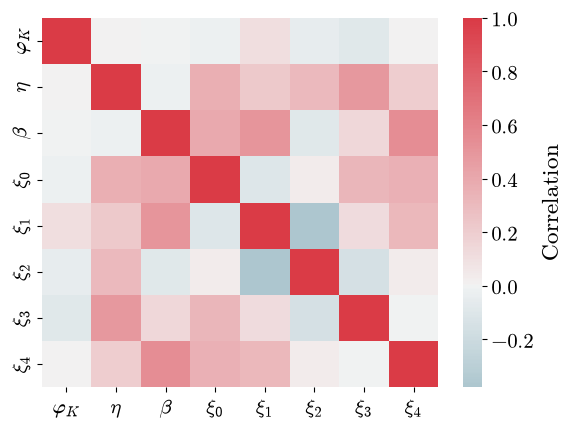

In [15]:

symbols_eig = dict(map(lambda x: ("eig_" + str(x), r"$\xi_{%d}$" % x), range(5)))
symbols_features = {"phi_K": r"$\varphi_K$", "eta": r"$\eta$", "beta": r"$\beta$", **symbols_eig}
ax_2 = sns.heatmap(corr_mat, cmap=sns.diverging_palette(220, 10, as_cmap=True), xticklabels = symbols_features.values(), yticklabels = symbols_features.values(), center=0,
    cbar_kws={"label": "Correlation"})
cbar_ax = ax_2.collections[0].colorbar.ax
cbar_ax.tick_params(labelsize=15)
cbar_ax.yaxis.label.set_size(17)
ax_2.tick_params(axis='x', labelsize=15)
ax_2.tick_params(axis='y', labelsize=15)
plt.savefig("../Thesis_Docs/pictures/fig24.pdf", bbox_inches="tight", pad_inches=0)

In [16]:
torch.cuda.get_device_properties(torch.device("cuda"))

_CudaDeviceProperties(name='AMD Radeon Graphics', major=10, minor=3, gcnArchName='gfx1030', total_memory=8176MB, multi_processor_count=14, uuid=58580000-0000-0000-0000-000000000000, pci_bus_id=3, pci_device_id=0, pci_domain_id=0, L2_cache_size=2MB)

In [17]:
n_pow = 20
def custom_activation(x):
    return (1/n_pow) * torch.log((1 + torch.exp(n_pow * x)) / (1 + torch.exp(n_pow * (x - 1))))
#fin función

# Wrap the function in a Keras custom layer
@keras.saving.register_keras_serializable()
class CustomActivationLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Ensure inputs are Torch tensors
        inputs = torch.tensor(inputs) if not isinstance(inputs, torch.Tensor) else inputs
        return custom_activation(inputs)
    #fin función
#fin clase

def crear_modelo_de_regresion(lr_var, n_input_data):    
    modelo = keras.models.Sequential()
    modelo.add(keras.layers.Dense(64, activation = 'relu', input_shape = (n_input_data,)))
    modelo.add(keras.layers.Dense(32, activation = 'relu'))
    #modelo.add(keras.layers.Dense(16, activation = 'relu'))
    modelo.add(keras.layers.Dense(8, activation = 'relu'))
    modelo.add(keras.layers.Dense(1))
    modelo.add(CustomActivationLayer())
    modelo.compile(optimizer = keras.optimizers.RMSprop(learning_rate = lr_var), loss = 'mse', metrics = ['mae']) #RMSprop
    return modelo

In [18]:
k = 4 #4 sets de validación
n_muestras_val = len(X_train) // k
epocas = 100
all_history = []

In [19]:
if path_to_current_model == "none":
    modelo = crear_modelo_de_regresion(0.0005, len(features))
    history = modelo.fit(X_train, y_train, epochs = epocas, batch_size=16, 
                            validation_data = (X_rand5, y_rand5))
else:
    modelo = keras.models.load_model(path_to_current_model)
#fin if 

In [20]:
mets_train = data_processors.get_metrics(X_train, y_train, modelo)
mets_val = data_processors.get_metrics(X_rand5, y_rand5, modelo)
mets_rand1 = data_processors.get_metrics(X_rand1, y_rand1, modelo)

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [21]:
print("Train: ", mets_train)
print("Val: ", mets_val)
print("Test: ", mets_rand1)

Train:  {'R2': 0.980350388162379, 'RMSE': 0.040496441584180885, 'MAE': 0.025606780476329662, 'SDAE': np.float64(0.031372831791504525)}
Val:  {'R2': 0.9804636532175991, 'RMSE': 0.04044881071547472, 'MAE': 0.025599090084814237, 'SDAE': np.float64(0.03131761285803675)}
Test:  {'R2': 0.9808375108472563, 'RMSE': 0.04003268668648087, 'MAE': 0.025460084335909322, 'SDAE': np.float64(0.030893366746703538)}


In [64]:
N_sample = 200
datos_graph = datos_rand3.iloc[:N_sample]
datos_graph["M_real"] = np.random.uniform(10, 120, N_sample)
datos_graph["eig_0_no_norm"] = datos_graph["M_real"]*datos_graph["eig_0"]
datos_graph["eig_1_no_norm"] = datos_graph["M_real"]/datos_graph["eig_1"]
datos_graph["eig_2_no_norm"] = datos_graph["eig_1_no_norm"]/datos_graph["eig_2"]
datos_graph["eig_3_no_norm"] = datos_graph["eig_2_no_norm"]/datos_graph["eig_3"]
datos_graph["eig_4_no_norm"] = datos_graph["eig_3_no_norm"]/datos_graph["eig_4"]
datos_graph["eig_5_no_norm"] = datos_graph["eig_4_no_norm"]/datos_graph["eig_5"]
datos_graph["K"] = datos_graph["M_real"]*np.cos(datos_graph["phi_K"])
datos_graph["G"] = datos_graph["M_real"]*np.sin(datos_graph["phi_K"])
datos_graph["phi_K_pred"] = modelo.predict(datos_graph[features])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [65]:
datos_graph["eig_ref_0"] = 0.0
for i in datos_graph.index:
  phi_K_p = datos_graph.at[i, "phi_K_pred"]
  eta_g = datos_graph.at[i, "eta"]
  beta_g = datos_graph.at[i, "beta"]
  eig0_ref_l = eigenvals.forward_standard({"phi_K": phi_K_p}, eta_g, beta_g, "Parallelepiped", 6)["eig"]
  datos_graph.at[i, "eig_ref_0"] = eig0_ref_l[0]
  datos_graph.at[i, "eig_ref_1"] = eig0_ref_l[1]
  datos_graph.at[i, "eig_ref_2"] = eig0_ref_l[2]
  datos_graph.at[i, "eig_ref_3"] = eig0_ref_l[3]
  datos_graph.at[i, "eig_ref_4"] = eig0_ref_l[4]
  datos_graph.at[i, "eig_ref_5"] = eig0_ref_l[5]
datos_graph["M_pred"] = 1/6*(datos_graph["eig_0_no_norm"]/datos_graph["eig_ref_0"] +
                              datos_graph["eig_1_no_norm"]/datos_graph["eig_ref_1"] +
                              datos_graph["eig_2_no_norm"]/datos_graph["eig_ref_2"] +
                              datos_graph["eig_3_no_norm"]/datos_graph["eig_ref_3"] +
                              datos_graph["eig_4_no_norm"]/datos_graph["eig_ref_4"] +
                              datos_graph["eig_5_no_norm"]/datos_graph["eig_ref_5"])
datos_graph["K_pred"] = datos_graph["M_pred"]*np.cos(datos_graph["phi_K_pred"])
datos_graph["G_pred"] = datos_graph["M_pred"]*np.sin(datos_graph["phi_K_pred"])

In [66]:
datos_graph

,phi_K,eig_0,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5,x_0,...,phi_K_pred,eig_ref_0,eig_ref_1,eig_ref_2,eig_ref_3,eig_ref_4,eig_ref_5,M_pred,K_pred,G_pred
0,0.047254,0.250610,1.887066,2.596304,0.535584,0.983166,0.844317,0.998833,0.830581,0.368837,...,0.124950,0.421155,1.867133,1.891211,2.236190,2.247581,2.709575,47.583758,47.212787,5.930148
1,0.236073,1.156949,1.729958,2.692846,0.537178,0.904773,0.916235,0.977466,0.810346,0.352726,...,0.221687,0.702035,1.888100,2.057499,2.303298,2.304318,2.892763,54.054029,52.731216,11.885152
2,0.185918,0.003327,1.359813,0.329103,0.580186,0.365608,0.771851,0.747617,0.532120,0.065134,...,0.189996,0.002190,1.767905,5.050857,6.204977,8.310123,16.402516,14.455701,14.195571,2.730031
3,0.043784,0.010544,1.358984,0.831063,0.544146,0.339892,0.991994,0.744041,0.648951,0.088588,...,0.054251,0.008322,1.844122,5.460054,5.461894,7.340135,11.325178,116.811085,116.639230,6.334002
4,0.210726,0.727970,1.400031,3.015560,0.660152,0.950252,0.539729,0.937648,0.941250,0.298816,...,0.192205,0.427918,1.563285,1.645496,3.011986,3.168726,3.369678,91.850418,90.159022,17.545655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.444493,0.887536,1.346048,2.175771,0.762805,0.640018,0.569266,0.984474,0.959599,0.262552,...,0.429807,0.575749,1.423122,2.223269,3.701399,3.821526,3.889430,102.681657,93.342361,42.786994
196,0.725110,0.008047,1.394758,0.299373,0.796987,0.480831,0.490964,0.818351,0.654983,0.100847,...,0.749711,0.006215,1.598043,3.339633,5.797702,7.328968,12.619390,74.944997,54.851192,51.069549
197,0.889670,0.666612,1.305170,2.034858,0.593962,0.975887,0.663899,0.623302,0.933521,0.223915,...,0.912520,0.907588,1.146745,1.982472,3.553790,3.800778,3.873322,90.015972,55.067647,71.206943
198,0.488024,0.757921,1.108525,2.536324,0.933478,0.775348,0.436273,0.752887,0.999928,0.237716,...,0.473480,0.534007,1.035096,1.424957,3.261046,4.078883,4.096820,69.865809,62.179636,31.857872


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


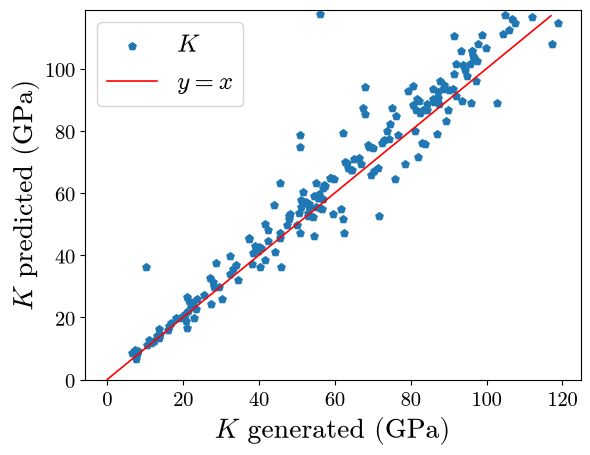

In [67]:
fig_K = plt.figure()
ax1 =fig_K.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(max(datos_graph["K"])))
ax1.scatter(datos_graph["K"], datos_graph["K_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$K$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$K$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(0, max(datos_graph["K"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$K$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_K.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


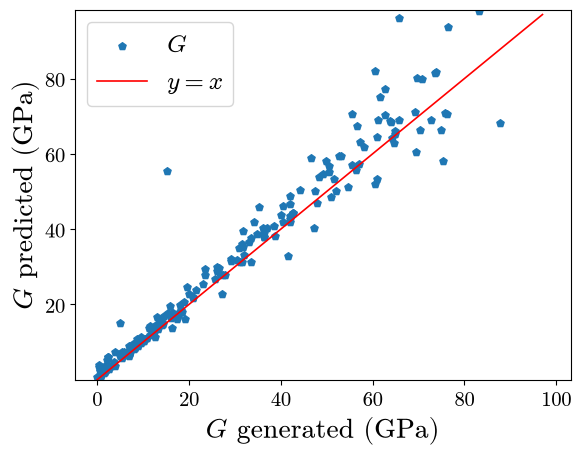

In [68]:
fig_G = plt.figure()
ax1 =fig_G.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(max(datos_graph["G"])))
ax1.scatter(datos_graph["G"], datos_graph["G_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$G$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$G$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["G"]), max(datos_graph["G"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$G$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_G.pdf", bbox_inches="tight", pad_inches=0)

In [63]:
path_archivo_kg = "../input_data/KG_random.csv"
str_to_ndarray = lambda x: np.fromstring(x, sep=' ')
datos_kg_random = pd.read_csv(path_archivo_kg, converters={'eigvals': str_to_ndarray})
datos_kg_random = datos_kg_random[datos_kg_random["shape"] == "parallelepiped"].copy()
datos_kg_random_std = data_processors.transform_full_sized_data_isotropic(datos_kg_random, N_eig)

In [21]:
datos_kg_random_std

,K,G,dx,dy,dz,shape,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,phi_K,eta,beta
98304,1.137564,0.925310,0.345791,0.722980,0.454774,parallelepiped,0.412707,0.524816,0.664249,1.242484,1.352123,1.526493,0.682866,1.337486,2.600392
98305,5.500412,5.321621,0.402060,0.999638,0.807374,parallelepiped,1.582053,2.487298,4.468703,4.838954,5.974758,6.092165,0.768879,1.468138,1.848136
98306,3.375617,3.980662,0.429638,0.851665,0.529495,parallelepiped,1.910220,2.281837,2.722189,5.154925,5.985199,6.880495,0.867462,1.350259,2.726644
98307,1.448420,4.074601,0.151318,0.942633,0.328977,parallelepiped,0.077098,0.249390,0.259526,0.483552,0.808482,1.025586,1.229252,0.733530,1.724437
98308,0.351677,5.407791,0.446276,0.792512,0.989446,parallelepiped,0.665386,1.100423,1.220930,1.825798,2.004655,2.115424,1.505856,1.486674,2.051426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131067,0.603325,3.002608,0.720661,0.439132,0.152189,parallelepiped,0.138335,0.260256,0.492664,0.812795,0.834834,0.876376,1.372503,1.145569,1.334456
131068,2.302202,2.474801,0.132153,0.607512,0.605882,parallelepiped,0.140488,0.296209,0.339297,0.719497,0.721766,1.428381,0.821514,1.591347,0.859013
131069,4.789391,3.091901,0.174914,0.402842,0.230977,parallelepiped,1.185878,1.416827,1.833425,3.694734,4.251125,4.515988,0.573257,1.247024,2.592575
131070,0.920026,0.420177,0.185685,0.716565,0.322597,parallelepiped,0.054970,0.067623,0.107235,0.267023,0.267814,0.273033,0.428413,0.958174,2.089119


In [22]:
datos_kg_random_copy = data_processors.preprocess_data(datos_kg_random_std, N_eig, target, opt = False)

In [23]:
datos_kg_random_copy

,phi_K,eig_0,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5
98304,0.434726,0.412707,1.337486,2.600392,0.786383,0.790090,0.534614,0.918914,0.885771
98305,0.489483,1.582053,1.468138,1.848136,0.636053,0.556604,0.923485,0.809900,0.980728
98306,0.552244,1.910220,1.350259,2.726644,0.837142,0.838236,0.528075,0.861279,0.869879
98307,0.782566,0.077098,0.733530,1.724437,0.309145,0.960942,0.536709,0.598099,0.788312
98308,0.958658,0.665386,1.486674,2.051426,0.604664,0.901299,0.668710,0.910779,0.947638
...,...,...,...,...,...,...,...,...,...
131067,0.873763,0.138335,1.145569,1.334456,0.531536,0.528263,0.606136,0.973601,0.952599
131068,0.522992,0.140488,1.591347,0.859013,0.474287,0.873008,0.471576,0.996856,0.505303
131069,0.364947,1.185878,1.247024,2.592575,0.836996,0.772776,0.496226,0.869119,0.941350
131070,0.272736,0.054970,0.958174,2.089119,0.812896,0.630602,0.401596,0.997046,0.980887


In [24]:
X_test3 = datos_kg_random_copy[features]
y_test3 = datos_kg_random_copy[target]

In [25]:
metrs3 = data_processors.get_metrics(X_test3, y_test3, modelo, mapes = True)

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [26]:
print("Datos KG_random Julián: ", metrs3)

Datos KG_random Julián:  {'R2': 0.9686027428658808, 'RMSE': np.float64(0.04142111670269494), 'MAE': np.float64(0.03046425274363833), 'SDAE': np.float64(0.028064892903234065), 'MAPE': np.float64(0.05665144088329244), 'SDPE': np.float64(0.09034494472290572)}


In [27]:
mets_combi = data_processors.get_metrics(X_combi, y_combi, modelo)

1641/1641 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [28]:
print("Mis datos combinatoriales: ", mets_combi)

Mis datos combinatoriales:  {'R2': 0.9867481740314671, 'RMSE': np.float64(0.033188830377180296), 'MAE': np.float64(0.022560716374172913), 'SDAE': np.float64(0.024341580443540886)}


In [29]:
if path_to_current_model == "none":
    modelo.save("models/isotropico_7.keras")
#fin if 

In [30]:
path_semiexp = "../input_data/KG_semiexp.csv"
datos_seexp = pd.read_csv(path_semiexp)
datos_seexp.head()

,phi_K,eta,beta,eig_0,eig_1,eig_2,eig_3,eig_4,eig_5,eig_6,...,eig_13,eig_14,eig_15,eig_16,eig_17,eig_18,eig_19,Parallelepiped,Cylinder,Ellipsoid
0,0.358691,0.263806,2.674015,0.002138,1.559783,7.433072,11.010617,11.099329,27.467240,36.616132,...,333.861874,468.431730,521.143351,585.047597,606.743064,877.646789,1310.107517,1,0,0
1,0.358691,0.263993,2.892086,0.002476,1.265481,7.353209,9.090068,10.087484,26.820308,32.268547,...,294.476409,431.922918,479.156885,508.630906,535.225772,814.017220,1259.706436,1,0,0
2,0.358691,0.400177,3.045061,0.013527,1.088295,4.343095,6.603833,7.074639,13.697794,18.561007,...,124.718264,185.911969,203.355272,208.974344,218.917350,257.672087,280.667061,1,0,0
3,0.358691,0.402585,3.141043,0.014468,1.000481,4.123985,6.539009,6.541562,12.976990,17.624350,...,117.682811,176.793479,194.647457,194.678789,207.248362,251.601696,251.723742,1,0,0
4,0.358691,0.254159,2.697156,0.001877,1.527850,7.464761,10.966756,11.729615,27.729201,38.811472,...,354.240574,499.781676,541.513430,612.463982,644.398190,938.188869,1506.517943,1,0,0


In [31]:
datos_seexp = data_processors.preprocess_data(datos_seexp, N_eig, target)
datos_seexp.head()

,phi_K,eig_0,eta,beta,eig_1,eig_2,eig_3,eig_4,eig_5
0,0.22835,0.002138,0.263806,2.674015,0.641115,0.209844,0.675082,0.992007,0.404093
1,0.22835,0.002476,0.263993,2.892086,0.790213,0.172099,0.808928,0.901123,0.376114
2,0.22835,0.013527,0.400177,3.045061,0.918869,0.250580,0.657663,0.933452,0.516480
3,0.22835,0.014468,0.402585,3.141043,0.999520,0.242600,0.630674,0.999610,0.504089
4,0.22835,0.001877,0.254159,2.697156,0.654515,0.204675,0.680672,0.934963,0.423006


In [32]:
X_seexp = datos_seexp[features]
y_seexp = datos_seexp[target]
mets_semiexp = data_processors.get_metrics(X_seexp, y_seexp, modelo, mapes=True)

688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [33]:
print(mets_semiexp)

{'R2': 0.630828903433684, 'RMSE': np.float64(0.07424863518429738), 'MAE': np.float64(0.059168737110785), 'SDAE': np.float64(0.04485443540438001), 'MAPE': np.float64(0.11665621593222149), 'SDPE': np.float64(0.10125611211762338)}


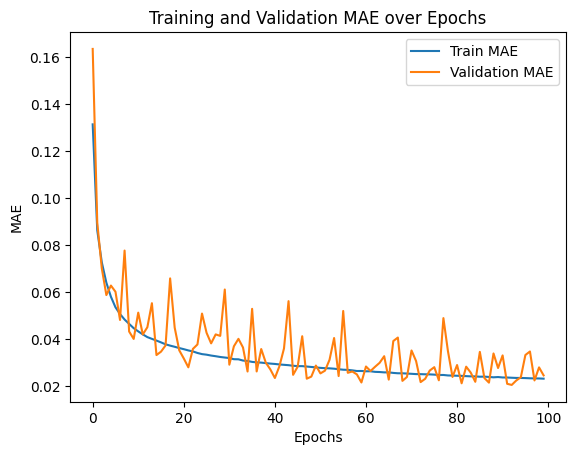

In [34]:
if path_to_current_model == "none":
    train_mae = history.history["mae"]
    val_mae = history.history["val_mae"]
    plt.figure()
    plt.plot(train_mae, label='Train MAE')
    plt.plot(val_mae, label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training and Validation MAE over Epochs')
    plt.legend()

In [35]:
if path_to_current_model == "none":
    import json
    with open('models/training_history_6.json', 'w') as f:
        json.dump(history.history, f)